In [6]:
import ee
import pandas as pd
import os

# Initialize GEE
credentials = ee.ServiceAccountCredentials(
    email='agroalert-service@ee-ishmaelfc.iam.gserviceaccount.com',
    key_file='C:/Users/ELITE/Documents/AGROALERT/service_account.json'
)
ee.Initialize(credentials)

# Define 5 test farming communities in Ghana
communities = [
    {"name": "Tamale",          "region": "Northern",       "lat": 9.4008,  "lon": -0.8393},
    {"name": "Techiman",        "region": "Bono East",      "lat": 7.5833,  "lon": -1.9333},
    {"name": "Kumasi",          "region": "Ashanti",        "lat": 6.6885,  "lon": -1.6244},
    {"name": "Ho",              "region": "Volta",          "lat": 6.6000,  "lon":  0.4700},
    {"name": "Bolgatanga",      "region": "Upper East",     "lat": 10.7856, "lon": -0.8514},
    {"name": "Wa",              "region": "Upper West",     "lat": 10.0601, "lon": -2.5099},
    {"name": "Sunyani",         "region": "Bono",           "lat": 7.3349,  "lon": -2.3123},
    {"name": "Koforidua",       "region": "Eastern",        "lat": 6.0940,  "lon": -0.2591},
    {"name": "Cape Coast",      "region": "Central",        "lat": 5.1053,  "lon": -1.2466},
    {"name": "Sefwi Wiawso",    "region": "Western North",  "lat": 6.2069,  "lon": -2.4856},
    {"name": "Damongo",         "region": "Savannah",       "lat": 9.0833,  "lon": -1.8167},
    {"name": "Nalerigu",        "region": "North East",     "lat": 10.5167, "lon": -0.3667},
    {"name": "Dambai",          "region": "Oti",            "lat": 8.0667,  "lon":  0.1833},
    {"name": "Goaso",           "region": "Ahafo",          "lat": 6.8017,  "lon": -2.5181},
    {"name": "Sekondi-Takoradi","region": "Western",        "lat": 4.9347,  "lon": -1.7137},
]

print(f"Communities defined: {len(communities)}")
for c in communities:
    print(f"  {c['name']} ({c['region']}) — {c['lat']}, {c['lon']}")

Communities defined: 15
  Tamale (Northern) — 9.4008, -0.8393
  Techiman (Bono East) — 7.5833, -1.9333
  Kumasi (Ashanti) — 6.6885, -1.6244
  Ho (Volta) — 6.6, 0.47
  Bolgatanga (Upper East) — 10.7856, -0.8514
  Wa (Upper West) — 10.0601, -2.5099
  Sunyani (Bono) — 7.3349, -2.3123
  Koforidua (Eastern) — 6.094, -0.2591
  Cape Coast (Central) — 5.1053, -1.2466
  Sefwi Wiawso (Western North) — 6.2069, -2.4856
  Damongo (Savannah) — 9.0833, -1.8167
  Nalerigu (North East) — 10.5167, -0.3667
  Dambai (Oti) — 8.0667, 0.1833
  Goaso (Ahafo) — 6.8017, -2.5181
  Sekondi-Takoradi (Western) — 4.9347, -1.7137


In [ ]:
# Function to get weekly NDVI for a community
def get_ndvi(community, start_date, end_date):
    point = ee.Geometry.Point([community['lon'], community['lat']])
    
    # Load Sentinel-2 satellite imagery
    collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(point)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(lambda img: img.normalizedDifference(['B8', 'B4'])
             .rename('NDVI')
             .set('date', img.date().format('YYYY-MM-dd'))))
    
    # Extract NDVI values
    def extract(img):
        val = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point.buffer(5000),
            scale=100
        )
        return ee.Feature(None, {
            'date': img.get('date'),
            'ndvi': val.get('NDVI'),
            'community': community['name'],
            'region': community['region']
        })
    
    features = collection.map(extract)
    return features

# Pull NDVI for all communities (2022-2023 to start)
all_features = ee.FeatureCollection([])
for community in communities:
    fc = get_ndvi(community, '2022-01-01', '2023-12-31')
    all_features = all_features.merge(fc)

print("Fetching NDVI data from satellite...")
data = all_features.getInfo()
print(f"Total records fetched: {len(data['features'])}")

Fetching NDVI data from satellite...


In [ ]:
# Convert to pandas dataframe
records = []
for feature in data['features']:
    props = feature['properties']
    records.append({
        'community': props.get('community'),
        'region': props.get('region'),
        'date': props.get('date'),
        'ndvi': props.get('ndvi')
    })

df_ndvi = pd.DataFrame(records)

# Sort by community and date
df_ndvi['date'] = pd.to_datetime(df_ndvi['date'])
df_ndvi = df_ndvi.sort_values(['community', 'date']).reset_index(drop=True)

# Drop rows with no NDVI value
df_ndvi = df_ndvi.dropna(subset=['ndvi'])

# Save to CSV
os.makedirs('C:/Users/ELITE/Documents/AGROALERT/data_raw', exist_ok=True)
df_ndvi.to_csv('C:/Users/ELITE/Documents/AGROALERT/data_raw/ndvi_raw.csv', index=False)

print(f"Records saved: {len(df_ndvi)}")
print(f"\nSample data:")
print(df_ndvi.head(10))
print(f"\nNDVI range: {df_ndvi['ndvi'].min():.3f} to {df_ndvi['ndvi'].max():.3f}")

Records saved: 247

Sample data:
    community      region       date      ndvi
0  Bolgatanga  Upper East 2022-01-01  0.208887
1  Bolgatanga  Upper East 2022-01-01  0.206289
2  Bolgatanga  Upper East 2022-01-06  0.185902
3  Bolgatanga  Upper East 2022-01-06  0.183972
4  Bolgatanga  Upper East 2022-01-11  0.182980
5  Bolgatanga  Upper East 2022-01-16  0.192266
6  Bolgatanga  Upper East 2022-01-16  0.193062
7  Bolgatanga  Upper East 2022-01-21  0.185358
8  Bolgatanga  Upper East 2022-01-21  0.183661
9  Bolgatanga  Upper East 2022-01-26  0.199298

NDVI range: 0.021 to 0.595


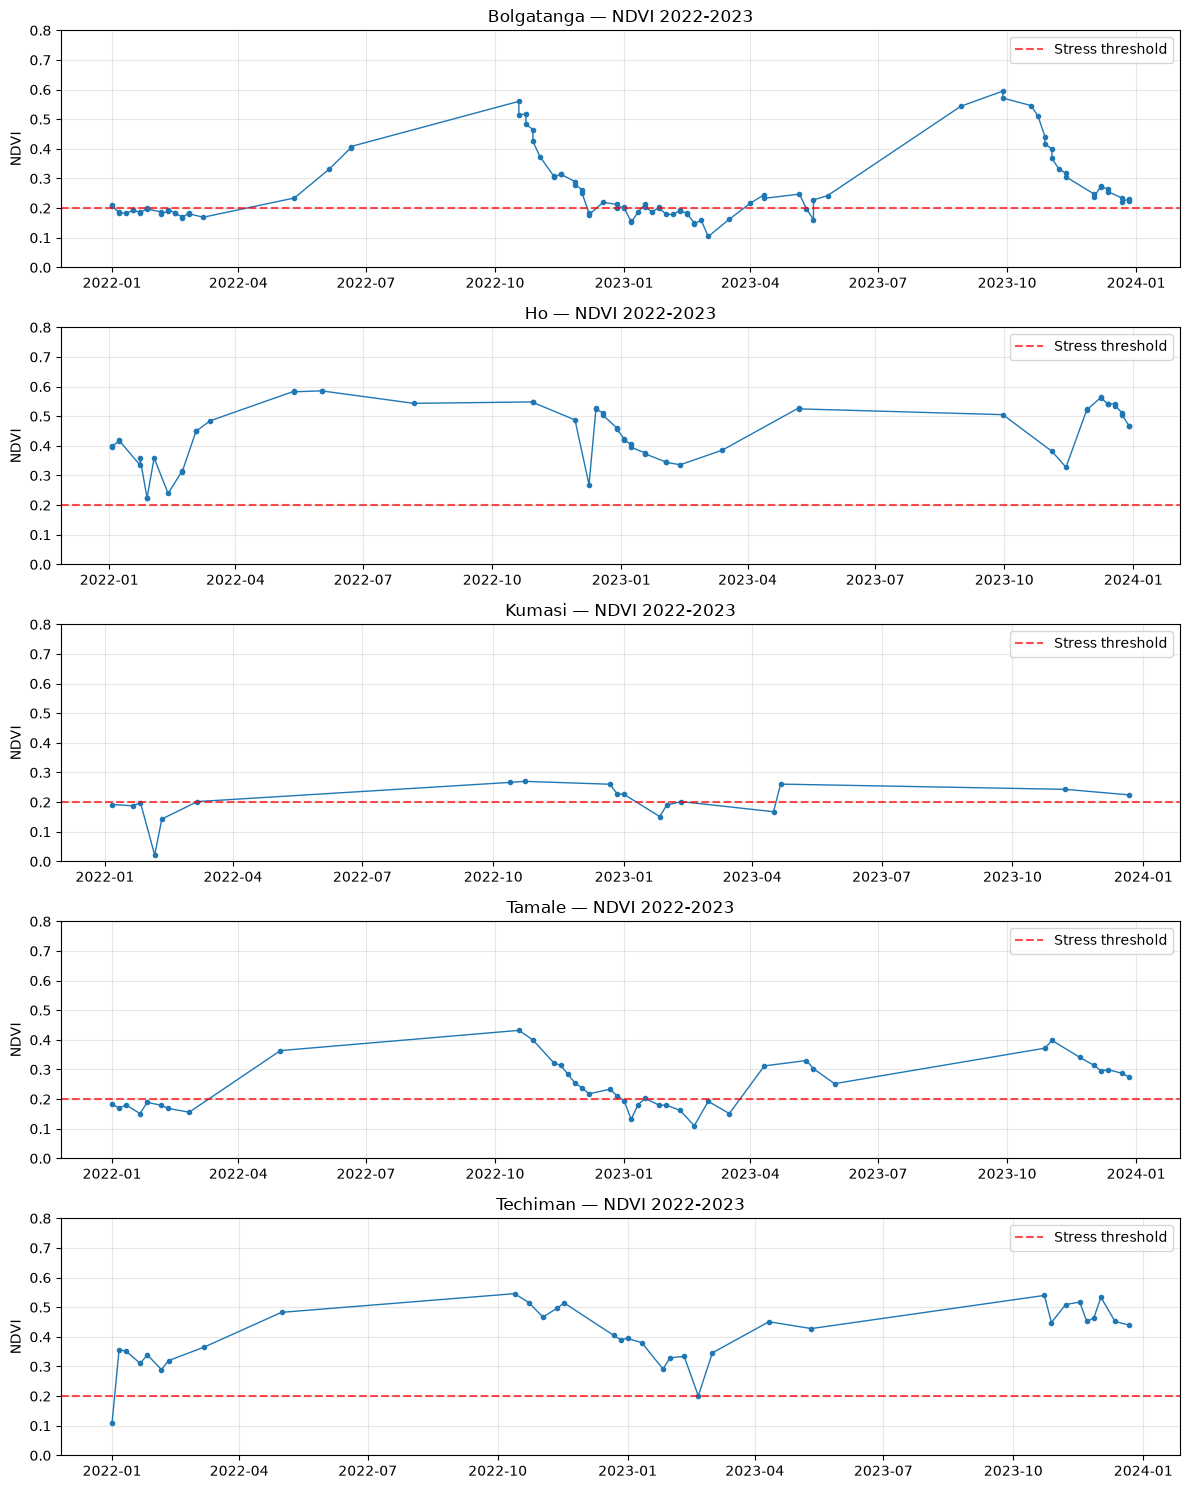

Plot saved!


In [ ]:
import matplotlib.pyplot as plt

# Plot NDVI over time for each community
fig, axes = plt.subplots(5, 1, figsize=(12, 15))

for i, community_name in enumerate(df_ndvi['community'].unique()):
    df_c = df_ndvi[df_ndvi['community'] == community_name]
    axes[i].plot(df_c['date'], df_c['ndvi'], marker='o', markersize=3, linewidth=1)
    axes[i].axhline(y=0.2, color='red', linestyle='--', alpha=0.7, label='Stress threshold')
    axes[i].set_title(f'{community_name} — NDVI 2022-2023')
    axes[i].set_ylabel('NDVI')
    axes[i].set_ylim(0, 0.8)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/ELITE/Documents/AGROALERT/data_raw/ndvi_plot.png', dpi=150)
plt.show()
print("Plot saved!")

In [2]:
import ee
import pandas as pd

credentials = ee.ServiceAccountCredentials(
    email='agroalert-service@ee-ishmaelfc.iam.gserviceaccount.com',
    key_file='C:/Users/ELITE/Documents/AGROALERT/service_account.json'
)
ee.Initialize(credentials)

communities = [
    {"name": "Tamale",           "region": "Northern",      "lat": 9.4008,  "lon": -0.8393},
    {"name": "Techiman",         "region": "Bono East",     "lat": 7.5833,  "lon": -1.9333},
    {"name": "Kumasi",           "region": "Ashanti",       "lat": 6.6885,  "lon": -1.6244},
    {"name": "Ho",               "region": "Volta",         "lat": 6.6000,  "lon":  0.4700},
    {"name": "Bolgatanga",       "region": "Upper East",    "lat": 10.7856, "lon": -0.8514},
    {"name": "Wa",               "region": "Upper West",    "lat": 10.0601, "lon": -2.5099},
    {"name": "Sunyani",          "region": "Bono",          "lat": 7.3349,  "lon": -2.3123},
    {"name": "Koforidua",        "region": "Eastern",       "lat": 6.0940,  "lon": -0.2591},
    {"name": "Cape Coast",       "region": "Central",       "lat": 5.1053,  "lon": -1.2466},
    {"name": "Sefwi Wiawso",     "region": "Western North", "lat": 6.2069,  "lon": -2.4856},
    {"name": "Damongo",          "region": "Savannah",      "lat": 9.0833,  "lon": -1.8167},
    {"name": "Nalerigu",         "region": "North East",    "lat": 10.5167, "lon": -0.3667},
    {"name": "Dambai",           "region": "Oti",           "lat": 8.0667,  "lon":  0.1833},
    {"name": "Goaso",            "region": "Ahafo",         "lat": 6.8017,  "lon": -2.5181},
    {"name": "Sekondi-Takoradi", "region": "Western",       "lat": 4.9347,  "lon": -1.7137},
]

def get_ndvi(community, start_date, end_date):
    point = ee.Geometry.Point([community['lon'], community['lat']])
    collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(point)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(lambda img: img.normalizedDifference(['B8', 'B4'])
             .rename('NDVI')
             .set('date', img.date().format('YYYY-MM-dd'))))
    def extract(img):
        val = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point.buffer(5000),
            scale=100
        )
        return ee.Feature(None, {
            'date': img.get('date'),
            'ndvi': val.get('NDVI'),
            'community': community['name'],
            'region': community['region']
        })
    return collection.map(extract)

print("Pulling NDVI for 15 communities — this may take 3-5 minutes...")
all_features = ee.FeatureCollection([])
for i, community in enumerate(communities):
    fc = get_ndvi(community, '2022-01-01', '2023-12-31')
    all_features = all_features.merge(fc)
    print(f"  Queued {i+1}/15: {community['name']}")

print("\nFetching from GEE servers...")
data = all_features.getInfo()

records = []
for feature in data['features']:
    props = feature['properties']
    if props.get('ndvi') is not None:
        records.append({
            'community': props.get('community'),
            'region': props.get('region'),
            'date': props.get('date'),
            'ndvi': props.get('ndvi')
        })

df_ndvi = pd.DataFrame(records)
df_ndvi['date'] = pd.to_datetime(df_ndvi['date'])
df_ndvi = df_ndvi.sort_values(['community','date']).reset_index(drop=True)
df_ndvi.to_csv('C:/Users/ELITE/Documents/AGROALERT/data_raw/ndvi_raw.csv', index=False)

print(f"\nTotal NDVI records: {len(df_ndvi)}")
print(f"Communities with data: {df_ndvi['community'].nunique()}")
print(df_ndvi['community'].value_counts())

Pulling NDVI for 15 communities — this may take 3-5 minutes...
  Queued 1/15: Tamale
  Queued 2/15: Techiman
  Queued 3/15: Kumasi
  Queued 4/15: Ho
  Queued 5/15: Bolgatanga
  Queued 6/15: Wa
  Queued 7/15: Sunyani
  Queued 8/15: Koforidua
  Queued 9/15: Cape Coast
  Queued 10/15: Sefwi Wiawso
  Queued 11/15: Damongo
  Queued 12/15: Nalerigu
  Queued 13/15: Dambai
  Queued 14/15: Goaso
  Queued 15/15: Sekondi-Takoradi

Fetching from GEE servers...

Total NDVI records: 681
Communities with data: 15
community
Dambai              117
Bolgatanga           97
Ho                   57
Sunyani              57
Wa                   52
Koforidua            48
Damongo              47
Nalerigu             47
Tamale               41
Goaso                37
Techiman             34
Kumasi               18
Cape Coast           11
Sekondi-Takoradi     11
Sefwi Wiawso          7
Name: count, dtype: int64
